In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [3]:
from src.getdata_utils import load_data, split_data

In [4]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [18]:
df2 = df.drop(columns=['duration'])


In [19]:
df2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [7]:
df3=df2.copy()

In [8]:
import statsmodels.api as sm
from patsy import dmatrices

# Convert target to binary numeric
df3['y_binary'] = df3['y'].map({'no': 0, 'yes': 1})

# Formula (categorical vars wrapped in C())
formula = 'y_binary ~ age + C(job) + C(marital) + C(education) + default + balance + housing + loan + C(contact) + day + C(month)  + campaign + pdays + previous + C(poutcome)'

# Create design matrices
y, X = dmatrices(formula, data=df3, return_type='dataframe')

# Convert y to 1D
y = y['y_binary']

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.300281
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               y_binary   No. Observations:                45211
Model:                          Logit   Df Residuals:                    45169
Method:                           MLE   Df Model:                           41
Date:                Sun, 17 Aug 2025   Pseudo R-squ.:                  0.1679
Time:                        01:11:40   Log-Likelihood:                -13576.
converged:                       True   LL-Null:                       -16315.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.2914      0.163     -7.911      0.000      -1.

In [9]:
# Get p-values and coefficients
summary_df = pd.DataFrame({
    'feature': result.params.index,
    'coef': result.params.values,
    'p_value': result.pvalues.values
})

# Sort by p-value (ascending: most significant first)
summary_df = summary_df.sort_values(by='p_value')

print(summary_df)


                      feature      coef        p_value
34     C(poutcome)[T.success]  2.235447  4.973289e-192
21      C(contact)[T.unknown] -1.339807   7.100339e-99
18             housing[T.yes] -0.524630   3.387434e-42
22            C(month)[T.aug] -0.831181   1.475232e-32
30            C(month)[T.nov] -0.858081   2.467908e-30
25            C(month)[T.jan] -1.120106   2.945273e-25
26            C(month)[T.jul] -0.699211   1.104757e-24
39                   campaign -0.086827   4.017595e-24
28            C(month)[T.mar]  1.107193   2.107952e-23
0                   Intercept -1.291381   2.550782e-15
19                loan[T.yes] -0.396288   9.266553e-14
29            C(month)[T.may] -0.464197   5.518386e-13
31            C(month)[T.oct]  0.643961   4.550050e-11
32            C(month)[T.sep]  0.672959   5.320335e-10
15   C(education)[T.tertiary]  0.315000   2.042908e-06
24            C(month)[T.feb] -0.370477   3.308439e-06
5           C(job)[T.retired]  0.400219   3.803955e-06
12      C(

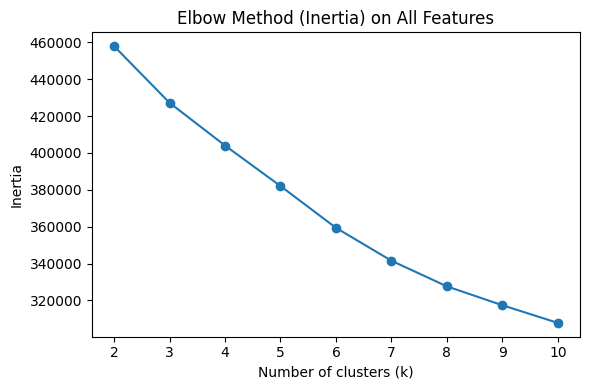

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# --- 1) Split features: numeric vs categorical ---
num_features = ['age','balance','day','duration','campaign','pdays','previous']
target_col = 'y'  # adjust if your target is named differently

X = df.drop(columns=[target_col]) if target_col in df.columns else df
cat_features = [c for c in X.columns if c not in num_features]

# --- 2) Preprocessor: scale nums, one-hot encode cats ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ],
    remainder='drop'
)

# --- 3) Elbow / Inertia across k ---
K_range = range(2, 11)  # try k = 2..10
inertias = []

for k in K_range:
    pipe = Pipeline(steps=[
        ('prep', preprocessor),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    pipe.fit(X)
    inertias.append(pipe.named_steps['kmeans'].inertia_)

# --- 4) Plot elbow curve ---
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method (Inertia) on All Features')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


Best k by silhouette: 2  (score=0.2169)


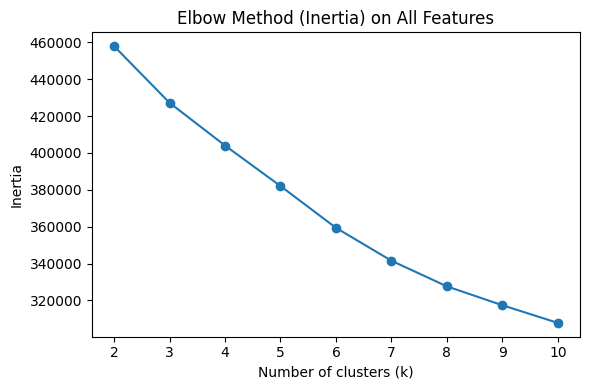

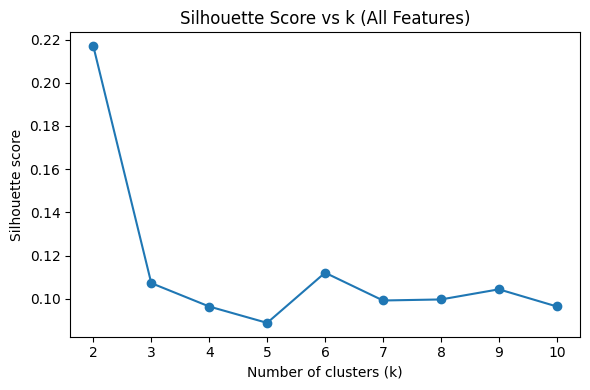

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ===== 0) (Optional) Sample for speed on large data =====
# df = df.sample(10000, random_state=42)

# ===== 1) Build feature matrix X (drop target if present) =====
target_col = 'y'
X = df.drop(columns=[target_col]) if target_col in df.columns else df

# Expected numeric features (some may be missing)
expected_num = ['age','balance','day','duration','campaign','pdays','previous']
num_features = [c for c in expected_num if c in X.columns]
if missing := [c for c in expected_num if c not in X.columns]:
    print(f"Note: missing numeric columns skipped -> {missing}")

# Everything else is treated as categorical
cat_features = [c for c in X.columns if c not in num_features]

# ===== 2) Preprocessor: scale nums, one-hot encode cats (dense) =====
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)         # older sklearn

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', ohe, cat_features),
    ],
    remainder='drop'
)

# Fit once and transform to a numeric matrix for clustering
X_proc = preprocessor.fit_transform(X)

# ===== 3) Evaluate across k using inertia + silhouette =====
K_range = range(2, 11)  # k = 2..10
inertias = []
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_proc)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_proc, labels, metric='euclidean')
    sil_scores.append(sil)

best_k_by_sil = int(K_range[np.argmax(sil_scores)])
print(f"Best k by silhouette: {best_k_by_sil}  (score={max(sil_scores):.4f})")

# ===== 4) Plot (separate figures, no specific colors) =====
# Elbow plot
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method (Inertia) on All Features')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

# Silhouette plot
plt.figure(figsize=(6,4))
plt.plot(list(K_range), sil_scores, marker='o')
plt.title('Silhouette Score vs k (All Features)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN

# ===== 1) Build feature matrix X (drop target if present) =====
target_col = 'y'
X = df.drop(columns=[target_col]) if target_col in df.columns else df

# Numeric and categorical split
expected_num = ['age','balance','day','duration','campaign','pdays','previous']
num_features = [c for c in expected_num if c in X.columns]
cat_features = [c for c in X.columns if c not in num_features]

# ===== 2) Preprocessor: scale nums + one-hot encode cats =====
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # sklearn >=1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', ohe, cat_features),
    ],
    remainder='drop'
)

# ===== 3) DBSCAN pipeline =====
dbscan = Pipeline(steps=[
    ('prep', preprocessor),
    ('db', DBSCAN(eps=0.5, min_samples=5))  # adjust eps/min_samples
])

# ===== 4) Fit model =====
dbscan.fit(X)

# Extract labels (-1 = noise/outlier)
labels = dbscan.named_steps['db'].labels_
df['dbscan_cluster'] = labels

# ===== 5) Inspect cluster counts =====
print(df['dbscan_cluster'].value_counts())


dbscan_cluster
-1      40082
 3        448
 6        261
 160      190
 45       149
        ...  
 284        4
 84         4
 271        4
 182        3
 99         3
Name: count, Length: 305, dtype: int64


In [23]:
cluster3 = df[df['dbscan_cluster'] == 3]
print(cluster3.describe(include='all'))


               age          job  marital  education default      balance  \
count   448.000000          448      448        448     448   448.000000   
unique         NaN            1        1          1       1          NaN   
top            NaN  blue-collar  married  secondary      no          NaN   
freq           NaN          448      448        448     448          NaN   
mean     37.839286          NaN      NaN        NaN     NaN   453.381696   
std       7.404640          NaN      NaN        NaN     NaN   695.430949   
min      24.000000          NaN      NaN        NaN     NaN -1500.000000   
25%      32.000000          NaN      NaN        NaN     NaN    31.500000   
50%      36.000000          NaN      NaN        NaN     NaN   270.000000   
75%      42.000000          NaN      NaN        NaN     NaN   662.500000   
max      59.000000          NaN      NaN        NaN     NaN  4996.000000   

       housing loan  contact         day month    duration    campaign  pdays  \
count 

In [24]:
pd.crosstab(df['dbscan_cluster'], df['marital'], normalize='index')
pd.crosstab(df['dbscan_cluster'], df['education'], normalize='index')


education,primary,secondary,tertiary,unknown
dbscan_cluster,,,,
-1,0.150267,0.507535,0.296143,0.046056
0,0.000000,0.000000,1.000000,0.000000
1,0.000000,1.000000,0.000000,0.000000
2,0.000000,1.000000,0.000000,0.000000
3,0.000000,1.000000,0.000000,0.000000
...,...,...,...,...
299,0.000000,0.000000,1.000000,0.000000
300,0.000000,1.000000,0.000000,0.000000
301,0.000000,1.000000,0.000000,0.000000


[0]	train-auc:0.71991	valid-auc:0.73691
[1]	train-auc:0.72790	valid-auc:0.74675
[2]	train-auc:0.74285	valid-auc:0.76488
[3]	train-auc:0.74695	valid-auc:0.76610
[4]	train-auc:0.75073	valid-auc:0.76686
[5]	train-auc:0.74968	valid-auc:0.76601
[6]	train-auc:0.75250	valid-auc:0.76938
[7]	train-auc:0.75276	valid-auc:0.76905
[8]	train-auc:0.75378	valid-auc:0.76896
[9]	train-auc:0.75529	valid-auc:0.77037
[10]	train-auc:0.75510	valid-auc:0.76947
[11]	train-auc:0.75509	valid-auc:0.76956
[12]	train-auc:0.75703	valid-auc:0.77204
[13]	train-auc:0.75615	valid-auc:0.77122
[14]	train-auc:0.75776	valid-auc:0.77390
[15]	train-auc:0.75850	valid-auc:0.77463
[16]	train-auc:0.75925	valid-auc:0.77505
[17]	train-auc:0.76041	valid-auc:0.77576
[18]	train-auc:0.76156	valid-auc:0.77618
[19]	train-auc:0.76248	valid-auc:0.77642
[20]	train-auc:0.76330	valid-auc:0.77638
[21]	train-auc:0.76494	valid-auc:0.77733
[22]	train-auc:0.76515	valid-auc:0.77746
[23]	train-auc:0.76555	valid-auc:0.77783
[24]	train-auc:0.76515	val

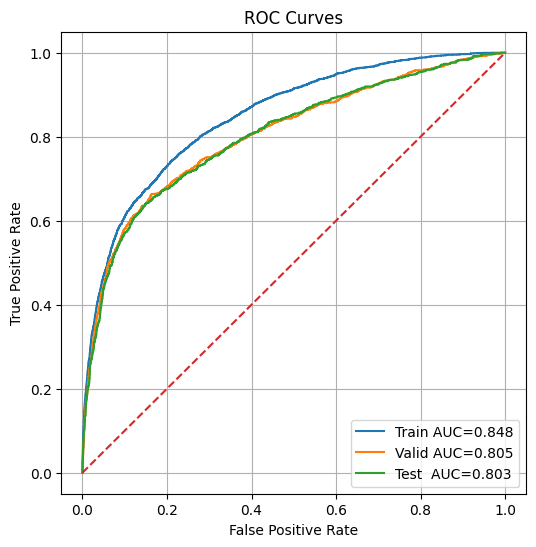

In [11]:
# =========================
# Full, ready-to-run script
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score, roc_auc_score, roc_curve, classification_report,
    precision_recall_curve
)

# ---------------------------------------
# 1) Target & features (uses df2)
# ---------------------------------------
y = df2['y'].map({'no': 0, 'yes': 1})
X = df2.drop(columns=['y'])

num_cols = [c for c in ['age','balance','day','campaign','pdays','previous'] if c in X.columns]
cat_cols = [c for c in ['job','default','education','loan','housing','contact','month','poutcome'] if c in X.columns]

# ---------------------------------------
# 2) Preprocessing (sparse-friendly)
#    - OneHotEncoder(sparse)
#    - StandardScaler(with_mean=False) to keep sparse compatibility
# ---------------------------------------
try:
    ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=True)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse=True)        # older sklearn

preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=False), num_cols),
        ('cat', ohe, cat_cols),
    ],
    remainder='drop',
    sparse_threshold=1.0  # keep output sparse when possible
)

# ---------------------------------------
# 3) Split
# ---------------------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)  # 60/20/20

# Fit preprocessor and transform to sparse matrices
preproc.fit(X_train)
Xtr = preproc.transform(X_train)
Xva = preproc.transform(X_val)
Xte = preproc.transform(X_test)

# ---------------------------------------
# 4) Imbalance handling via scale_pos_weight
# ---------------------------------------
neg, pos = np.bincount(y_train)
spw = neg / max(pos, 1)

# ---------------------------------------
# 5) XGBoost Booster training with early stopping (version-agnostic)
# ---------------------------------------
# Convert to DMatrix (fast + handles scipy sparse)
dtr = xgb.DMatrix(Xtr, label=y_train)
dva = xgb.DMatrix(Xva, label=y_val)
dte = xgb.DMatrix(Xte, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "eta": 0.03,            # learning_rate
    "max_depth": 4,
    "min_child_weight": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,          # reg_lambda
    "alpha": 0.0,           # reg_alpha
    "scale_pos_weight": spw,
    "verbosity": 0
}

num_boost_round = 3000
bst = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=num_boost_round,
    evals=[(dtr, "train"), (dva, "valid")],
    early_stopping_rounds=100
)

# ---------------------------------------
# 6) Predictions (probabilities)
# ---------------------------------------
proba_tr = bst.predict(dtr, iteration_range=(0, bst.best_iteration + 1))
proba_va = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
proba_te = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))

# ---------------------------------------
# 7) Evaluation helpers
# ---------------------------------------
def eval_block(split, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    print(f"\n=== {split} @ thr={thr:.3f} ===")
    print(f"Accuracy:          {accuracy_score(y_true, pred):.3f}")
    print(f"Recall:            {recall_score(y_true, pred):.3f}")
    print(f"Precision:         {precision_score(y_true, pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, pred):.3f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, proba):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_true, pred))

def plot_roc(y_tr, p_tr, y_v, p_v, y_te, p_te):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_v,  tpr_v,  _ = roc_curve(y_v,  p_v)
    fpr_te, tpr_te, _ = roc_curve(y_te, p_te)
    auc_tr = roc_auc_score(y_tr, p_tr)
    auc_v  = roc_auc_score(y_v,  p_v)
    auc_te = roc_auc_score(y_te, p_te)

    plt.figure(figsize=(6,6))
    plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={auc_tr:.3f}")
    plt.plot(fpr_v,  tpr_v,  label=f"Valid AUC={auc_v:.3f}")
    plt.plot(fpr_te, tpr_te, label=f"Test  AUC={auc_te:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

def tune_threshold_by_f1(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    idx = int(np.nanargmax(f1s))
    best_thr = float(thr[max(idx-1, 0)]) if len(thr) > 0 else 0.5
    return best_thr, float(np.nanmax(f1s))

# ---------------------------------------
# 8) Evaluate (0.5 and tuned threshold)
# ---------------------------------------
eval_block("Train (0.5)", y_train, proba_tr, 0.5)
eval_block("Valid (0.5)", y_val,   proba_va, 0.5)
eval_block("Test  (0.5)", y_test,  proba_te, 0.5)

best_thr, best_f1 = tune_threshold_by_f1(y_val, proba_va)
print(f"\nBest Val threshold by F1: {best_thr:.3f}  (F1={best_f1:.3f})")

eval_block("Train (tuned)", y_train, proba_tr, best_thr)
eval_block("Valid (tuned)", y_val,   proba_va,  best_thr)
eval_block("Test  (tuned)", y_test,  proba_te,  best_thr)

plot_roc(y_train, proba_tr, y_val, proba_va, y_test, proba_te)


[0]	train-auc:0.71991	valid-auc:0.73691
[1]	train-auc:0.72790	valid-auc:0.74675
[2]	train-auc:0.74285	valid-auc:0.76488
[3]	train-auc:0.74695	valid-auc:0.76610
[4]	train-auc:0.75073	valid-auc:0.76686
[5]	train-auc:0.74968	valid-auc:0.76601
[6]	train-auc:0.75250	valid-auc:0.76938
[7]	train-auc:0.75276	valid-auc:0.76905
[8]	train-auc:0.75378	valid-auc:0.76896
[9]	train-auc:0.75529	valid-auc:0.77037
[10]	train-auc:0.75510	valid-auc:0.76947
[11]	train-auc:0.75509	valid-auc:0.76956
[12]	train-auc:0.75703	valid-auc:0.77204
[13]	train-auc:0.75615	valid-auc:0.77122
[14]	train-auc:0.75776	valid-auc:0.77390
[15]	train-auc:0.75850	valid-auc:0.77463
[16]	train-auc:0.75925	valid-auc:0.77505
[17]	train-auc:0.76041	valid-auc:0.77576
[18]	train-auc:0.76156	valid-auc:0.77618
[19]	train-auc:0.76248	valid-auc:0.77642
[20]	train-auc:0.76330	valid-auc:0.77638
[21]	train-auc:0.76494	valid-auc:0.77733
[22]	train-auc:0.76515	valid-auc:0.77746
[23]	train-auc:0.76555	valid-auc:0.77783
[24]	train-auc:0.76515	val

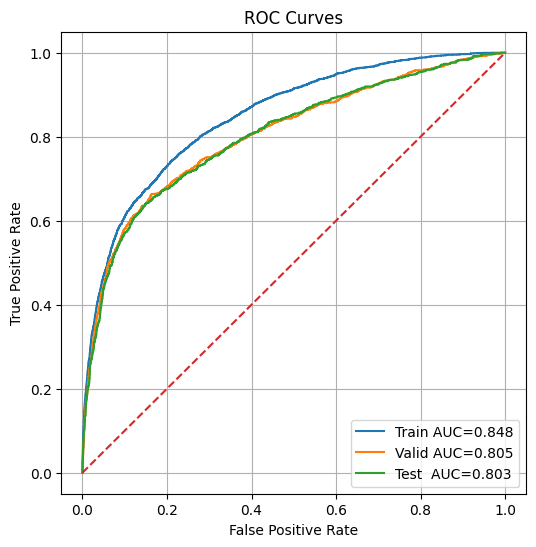

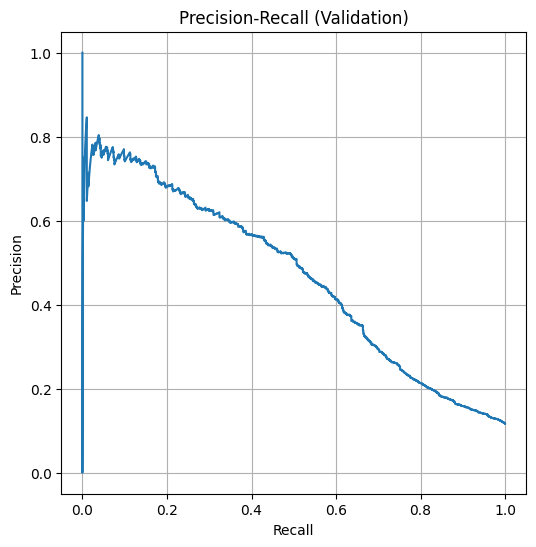

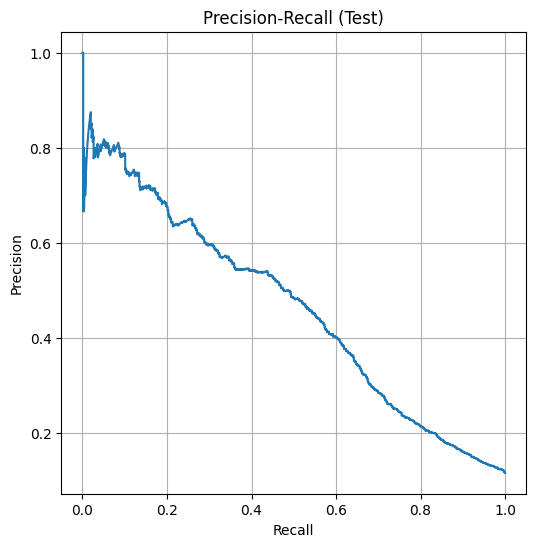

In [12]:
# =========================
# Full, ready-to-run script (df2)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score, roc_auc_score, roc_curve, classification_report,
    precision_recall_curve
)

# ---------------------------------------
# 1) Target & features (uses df2)
# ---------------------------------------
y = df2['y'].map({'no': 0, 'yes': 1})
X = df2.drop(columns=['y'])

num_cols = [c for c in ['age','balance','day','campaign','pdays','previous'] if c in X.columns]
cat_cols = [c for c in ['job','default','education','loan','housing','contact','month','poutcome'] if c in X.columns]

# ---------------------------------------
# 2) Preprocessing (sparse-friendly)
#    - OneHotEncoder(sparse)
#    - StandardScaler(with_mean=False) for sparse compatibility
# ---------------------------------------
try:
    ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=True)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse=True)        # older sklearn

preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=False), num_cols),
        ('cat', ohe, cat_cols),
    ],
    remainder='drop',
    sparse_threshold=1.0  # keep output sparse if possible
)

# ---------------------------------------
# 3) Split (60/20/20)
# ---------------------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Fit preprocessor and transform to sparse matrices
preproc.fit(X_train)
Xtr = preproc.transform(X_train)
Xva = preproc.transform(X_val)
Xte = preproc.transform(X_test)

# ---------------------------------------
# 4) Imbalance handling via scale_pos_weight
# ---------------------------------------
neg, pos = np.bincount(y_train)
spw = neg / max(pos, 1)

# ---------------------------------------
# 5) XGBoost Booster training with early stopping (version-agnostic)
# ---------------------------------------
# Convert to DMatrix (fast + handles scipy sparse)
dtr = xgb.DMatrix(Xtr, label=y_train)
dva = xgb.DMatrix(Xva, label=y_val)
dte = xgb.DMatrix(Xte, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "eta": 0.03,            # learning_rate
    "max_depth": 4,
    "min_child_weight": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,          # reg_lambda
    "alpha": 0.0,           # reg_alpha
    "scale_pos_weight": spw,
    "verbosity": 0
}

num_boost_round = 3000
bst = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=num_boost_round,
    evals=[(dtr, "train"), (dva, "valid")],
    early_stopping_rounds=100
)

# ---------------------------------------
# 6) Predictions (probabilities)
# ---------------------------------------
proba_tr = bst.predict(dtr, iteration_range=(0, bst.best_iteration + 1))
proba_va = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
proba_te = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))

# ---------------------------------------
# 7) Evaluation helpers (includes Balanced Accuracy)
# ---------------------------------------
def eval_block(split, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    print(f"\n=== {split} @ thr={thr:.3f} ===")
    print(f"Accuracy:          {accuracy_score(y_true, pred):.3f}")
    print(f"Recall:            {recall_score(y_true, pred):.3f}")
    print(f"Precision:         {precision_score(y_true, pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, pred):.3f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, proba):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_true, pred))

def plot_roc(y_tr, p_tr, y_v, p_v, y_te, p_te):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_v,  tpr_v,  _ = roc_curve(y_v,  p_v)
    fpr_te, tpr_te, _ = roc_curve(y_te, p_te)
    auc_tr = roc_auc_score(y_tr, p_tr)
    auc_v  = roc_auc_score(y_v,  p_v)
    auc_te = roc_auc_score(y_te, p_te)

    plt.figure(figsize=(6,6))
    plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={auc_tr:.3f}")
    plt.plot(fpr_v,  tpr_v,  label=f"Valid AUC={auc_v:.3f}")
    plt.plot(fpr_te, tpr_te, label=f"Test  AUC={auc_te:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

def tune_threshold_by_f1(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    idx = int(np.nanargmax(f1s))
    best_thr = float(thr[max(idx-1, 0)]) if len(thr) > 0 else 0.5
    return best_thr, float(np.nanmax(f1s))

def tune_threshold_by_bal_acc(y_true, proba):
    # Sweep thresholds and pick the one maximizing Balanced Accuracy
    thresholds = np.linspace(0.05, 0.95, 181)  # step ~0.005
    best_thr, best_ba = 0.5, -1.0
    for t in thresholds:
        pred = (proba >= t).astype(int)
        ba = balanced_accuracy_score(y_true, pred)
        if ba > best_ba:
            best_ba, best_thr = ba, t
    return float(best_thr), float(best_ba)

def plot_pr(y_true, proba, title="Precision-Recall"):
    prec, rec, _ = precision_recall_curve(y_true, proba)
    plt.figure(figsize=(6,6))
    plt.plot(rec, prec)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title)
    plt.grid(True); plt.show()

# ---------------------------------------
# 8) Evaluate (0.5 threshold)
# ---------------------------------------
eval_block("Train (0.5)", y_train, proba_tr, 0.5)
eval_block("Valid (0.5)", y_val,   proba_va, 0.5)
eval_block("Test  (0.5)", y_test,  proba_te, 0.5)

# ---------------------------------------
# 9) Tune threshold by F1 (validation) + re-eval
# ---------------------------------------
best_thr_f1, best_f1 = tune_threshold_by_f1(y_val, proba_va)
print(f"\nBest Val threshold by F1: {best_thr_f1:.3f}  (F1={best_f1:.3f})")
eval_block("Train (tuned F1)", y_train, proba_tr, best_thr_f1)
eval_block("Valid (tuned F1)", y_val,   proba_va,  best_thr_f1)
eval_block("Test  (tuned F1)", y_test,  proba_te,  best_thr_f1)

# ---------------------------------------
# 10) (Optional) Tune threshold by Balanced Accuracy + re-eval
# ---------------------------------------
best_thr_ba, best_ba = tune_threshold_by_bal_acc(y_val, proba_va)
print(f"\nBest Val threshold by Balanced Accuracy: {best_thr_ba:.3f}  (BA={best_ba:.3f})")
eval_block("Train (tuned BA)", y_train, proba_tr, best_thr_ba)
eval_block("Valid (tuned BA)", y_val,   proba_va,  best_thr_ba)
eval_block("Test  (tuned BA)", y_test,  proba_te,  best_thr_ba)

# ---------------------------------------
# 11) Plots: ROC + PR
# ---------------------------------------
plot_roc(y_train, proba_tr, y_val, proba_va, y_test, proba_te)
plot_pr(y_val,  proba_va, title="Precision-Recall (Validation)")
plot_pr(y_test, proba_te, title="Precision-Recall (Test)")


[0]	train-auc:0.72236	valid-auc:0.73434
[1]	train-auc:0.75670	valid-auc:0.76458
[2]	train-auc:0.76388	valid-auc:0.77622
[3]	train-auc:0.76618	valid-auc:0.78017
[4]	train-auc:0.76539	valid-auc:0.77985
[5]	train-auc:0.76589	valid-auc:0.77980
[6]	train-auc:0.76609	valid-auc:0.77921
[7]	train-auc:0.76389	valid-auc:0.77883
[8]	train-auc:0.76353	valid-auc:0.77845
[9]	train-auc:0.76511	valid-auc:0.77918
[10]	train-auc:0.76568	valid-auc:0.77925
[11]	train-auc:0.77018	valid-auc:0.78403
[12]	train-auc:0.77135	valid-auc:0.78597
[13]	train-auc:0.77387	valid-auc:0.78797
[14]	train-auc:0.77795	valid-auc:0.79020
[15]	train-auc:0.77946	valid-auc:0.79193
[16]	train-auc:0.78161	valid-auc:0.79250
[17]	train-auc:0.78167	valid-auc:0.79202
[18]	train-auc:0.78161	valid-auc:0.79171
[19]	train-auc:0.78243	valid-auc:0.79176
[20]	train-auc:0.78266	valid-auc:0.79195
[21]	train-auc:0.78281	valid-auc:0.79217
[22]	train-auc:0.78296	valid-auc:0.79220
[23]	train-auc:0.78261	valid-auc:0.79188
[24]	train-auc:0.78316	val

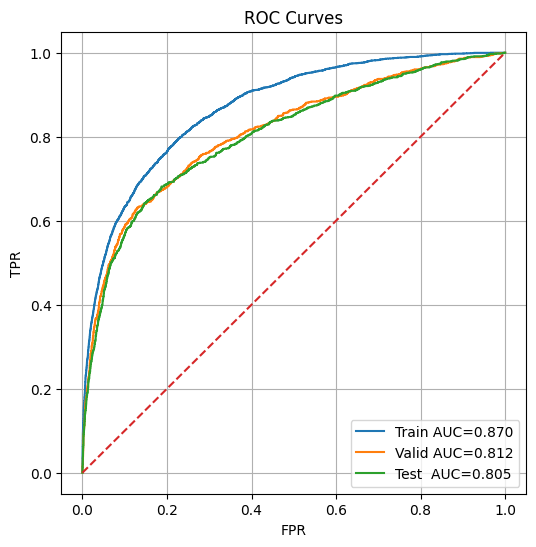

In [21]:
# =========================
# Full model script (df2)
# =========================
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score, roc_auc_score, roc_curve,
    classification_report, precision_recall_curve
)

# -----------------------------------------------------
# 1) Feature engineering tailored to df2 (no 'duration')
# -----------------------------------------------------
def feature_engineer_df2(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    # Safety checks
    req_cols = ['pdays', 'previous']
    for c in req_cols:
        if c not in out.columns:
            raise KeyError(f"Expected column '{c}' not found in df2.")

    # A) pdays signals
    p = out['pdays']
    out['was_contacted_before'] = (p != -1).astype(int)

    # pdays_bucket with explicit 'never' (use pandas Series to allow 'category')
    out['pdays_bucket'] = pd.Series(
        np.select(
            condlist=[
                p.eq(-1),          # never contacted before
                p.eq(0),           # same-day (current campaign)
                (p > 0) & (p <= 7),
                (p > 7) & (p <= 30),
                (p > 30) & (p <= 90),
                p > 90
            ],
            choicelist=['never', 'same_day', '1-7d', '8-30d', '31-90d', '90d+'],
            default='never'
        ),
        index=out.index
    ).astype('category')

    # Optional numeric recency (exclude "never")
    out['pdays_recency_num'] = np.where(p >= 0, p, np.nan)

    # B) previous signals
    out['prev_zero'] = (out['previous'] == 0).astype(int)
    out['prev_many'] = (out['previous'] > 3).astype(int)

    # C) Interactions / intensities
    if 'campaign' in out.columns:
        out['contact_history'] = out['previous'] + out['campaign']
        denom = (out['previous'] + out['campaign'] + 1)
        out['contact_rate'] = out['previous'] / denom
    else:
        out['contact_history'] = out['previous']
        out['contact_rate'] = out['previous'] / (out['previous'] + 1)

    # D) Month seasonality (cyclical encoding) if 'month' exists
    if 'month' in out.columns:
        month_map = {
            'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
            'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
        }
        mnum = out['month'].map(month_map).astype('float64')
        out['month_sin'] = np.sin(2 * np.pi * mnum / 12.0)
        out['month_cos'] = np.cos(2 * np.pi * mnum / 12.0)

    return out

# Apply FE (df2 is your original data)
df2_fe = feature_engineer_df2(df2)

# ---------------------------------------
# 2) Target & features
# ---------------------------------------
if 'y' not in df2_fe.columns:
    raise KeyError("Expected target column 'y' not found in df2.")

y = df2_fe['y'].map({'no': 0, 'yes': 1}).astype(int)
X = df2_fe.drop(columns=['y'])

# ---------------------------------------
# 3) Split (60/20/20)
# ---------------------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# ---------------------------------------
# 4) Preprocessing (sparse-friendly)
#    - Scale numeric (with_mean=False for sparse)
#    - One-hot categorical (sparse)
# ---------------------------------------
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

try:
    ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=True)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse=True)        # older sklearn

preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=False), num_cols),
        ('cat', ohe, cat_cols),
    ],
    remainder='drop',
    sparse_threshold=1.0  # keep output sparse when possible
)

# Fit transform to sparse matrices
preproc.fit(X_train)
Xtr = preproc.transform(X_train)
Xva = preproc.transform(X_val)
Xte = preproc.transform(X_test)

# ---------------------------------------
# 5) XGBoost (Booster API) with imbalance & early stopping
# ---------------------------------------
# Class imbalance handling
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / max(pos, 1)

# DMatrix
dtr = xgb.DMatrix(Xtr, label=y_train)
dva = xgb.DMatrix(Xva, label=y_val)
dte = xgb.DMatrix(Xte, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "eta": 0.03,              # learning_rate
    "max_depth": 5,           # shallower to reduce overfit
    "min_child_weight": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 2.0,            # stronger L2
    "alpha": 0.0,
    "scale_pos_weight": float(scale_pos_weight),
    "verbosity": 0
}

num_boost_round = 3000
bst = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=num_boost_round,
    evals=[(dtr, "train"), (dva, "valid")],
    early_stopping_rounds=100
)

# ---------------------------------------
# 6) Probabilities & metrics
# ---------------------------------------
proba_tr = bst.predict(dtr, iteration_range=(0, bst.best_iteration + 1))
proba_va = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
proba_te = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))

def eval_block(name, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    print(f"\n=== {name} @ thr={thr:.3f} ===")
    print(f"Accuracy:          {accuracy_score(y_true, pred):.3f}")
    print(f"Recall:            {recall_score(y_true, pred):.3f}")
    print(f"Precision:         {precision_score(y_true, pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, pred):.3f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, proba):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_true, pred))

def tune_threshold_by_f1(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    idx = int(np.nanargmax(f1s))
    best_thr = float(thr[max(idx-1, 0)]) if len(thr) > 0 else 0.5
    return best_thr, float(np.nanmax(f1s))

def tune_threshold_by_balacc(y_true, proba):
    thresholds = np.linspace(0.05, 0.95, 181)  # ~0.005 step
    best_thr, best_ba = 0.5, -1.0
    for t in thresholds:
        pred = (proba >= t).astype(int)
        ba = balanced_accuracy_score(y_true, pred)
        if ba > best_ba:
            best_ba, best_thr = ba, t
    return float(best_thr), float(best_ba)

# Evaluate @ 0.5
eval_block("Train", y_train, proba_tr, 0.5)
eval_block("Valid", y_val,   proba_va, 0.5)
eval_block("Test",  y_test,  proba_te, 0.5)

# Tune by F1 and re-eval
thr_f1, f1_val = tune_threshold_by_f1(y_val, proba_va)
print(f"\nBest validation threshold by F1: {thr_f1:.3f} (F1={f1_val:.3f})")
eval_block("Train (F1 thr)", y_train, proba_tr, thr_f1)
eval_block("Valid (F1 thr)", y_val,   proba_va,  thr_f1)
eval_block("Test  (F1 thr)", y_test,  proba_te,  thr_f1)

# Tune by Balanced Accuracy and re-eval (optional)
thr_ba, ba_val = tune_threshold_by_balacc(y_val, proba_va)
print(f"\nBest validation threshold by Balanced Accuracy: {thr_ba:.3f} (BA={ba_val:.3f})")
eval_block("Train (BA thr)", y_train, proba_tr, thr_ba)
eval_block("Valid (BA thr)", y_val,   proba_va,  thr_ba)
eval_block("Test  (BA thr)", y_test,  proba_te,  thr_ba)

# (Optional) ROC curves
fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_tr)
fpr_va, tpr_va, _ = roc_curve(y_val,   proba_va)
fpr_te, tpr_te, _ = roc_curve(y_test,  proba_te)

plt.figure(figsize=(6,6))
plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={roc_auc_score(y_train, proba_tr):.3f}")
plt.plot(fpr_va, tpr_va, label=f"Valid AUC={roc_auc_score(y_val,   proba_va):.3f}")
plt.plot(fpr_te, tpr_te, label=f"Test  AUC={roc_auc_score(y_test,  proba_te):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curves")
plt.legend(loc='lower right'); plt.grid(True); plt.show()


In [22]:
df2_fe.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,y,was_contacted_before,pdays_bucket,pdays_recency_num,prev_zero,prev_many,contact_history,contact_rate,month_sin,month_cos
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,no,0,never,NaN,1,0,1,0.0,0.5,-0.866025
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,no,0,never,NaN,1,0,1,0.0,0.5,-0.866025
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,no,0,never,NaN,1,0,1,0.0,0.5,-0.866025
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,no,0,never,NaN,1,0,1,0.0,0.5,-0.866025
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,no,0,never,NaN,1,0,1,0.0,0.5,-0.866025


In [23]:
df2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [5]:
df7=df.copy()

In [6]:
import pandas as pd

# Assuming your dataframe is named df

# 1. No_Previous_contact → 1 if pdays < 0 else 0
df7["No_Previous_contact"] = df7["pdays"].apply(lambda x: 1 if x < 0 else 0)

# 2. Not_contacted_for_prior_campaign → 1 if previous == 0 else 0
df7["Not_contacted_for_prior_campaign"] = df7["previous"].apply(lambda x: 1 if x == 0 else 0)

# 3. Combined flag → 1 if both conditions are true
df7["Never_contacted_before_No_Camapign_no_contact"] = ((df7["No_Previous_contact"] == 1) & 
                                (df7["Not_contacted_for_prior_campaign"] == 1)).astype(int)

# 4. Yearly balance groups → Low, Medium, High
df7["yearly_balance"] = pd.cut(
    df["balance"],
    bins=[-float("inf"), 20000, 60000, float("inf")],
    labels=["Low", "Medium", "High"]
)

# ✅ Preview new columns
print(df7[["pdays", "previous", "balance", 
          "No_Previous_contact", 
          "Not_contacted_for_prior_campaign", 
          "Never_contacted_before_No_Camapign_no_contact", 
          "yearly_balance"]].head(10))


   pdays  previous  balance  No_Previous_contact  \
0     -1         0     2143                    1   
1     -1         0       29                    1   
2     -1         0        2                    1   
3     -1         0     1506                    1   
4     -1         0        1                    1   
5     -1         0      231                    1   
6     -1         0      447                    1   
7     -1         0        2                    1   
8     -1         0      121                    1   
9     -1         0      593                    1   

   Not_contacted_for_prior_campaign  \
0                                 1   
1                                 1   
2                                 1   
3                                 1   
4                                 1   
5                                 1   
6                                 1   
7                                 1   
8                                 1   
9                                 1  

In [ ]:
# --- 0) Imports
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_cluster = df7.drop(columns=['y'])

# --- 1) Choose features for clustering (exclude target 'y')
num_features = [
    'age', 'balance', 'day', 'campaign', 'pdays', 'previous',
    'No_Previous_contact', 'Not_contacted_for_prior_campaign', 'Never_contacted_before_No_Camapign_no_contact'
]

cat_features = [
    'job','marital','education','default','housing','loan','contact','month','poutcome',
    'yearly_balance'   # your new Low/Medium/High band
]

use_cols = num_features + cat_features
X = df7[use_cols].copy()

# --- 2) Preprocess: scale numerics + one-hot encode categoricals
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_features)
    ]
)

# --- 3) KMeans (k=4)
kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', kmeans)
])

# --- 4) Fit & assign cluster labels
df['cluster'] = pipe.fit_predict(X)

# --- 5) Silhouette score (optional quality check; higher ~ better, up to 1.0)
X_proc = pipe.named_steps['preprocessor'].transform(X)
sil = silhouette_score(X_proc, df['cluster'])
print(f"Silhouette score (k=4): {sil:.3f}")

# --- 6) Quick cluster profiles

# 6a) Size of each cluster
print("\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

# 6b) Numeric means by cluster
print("\nNumeric feature means by cluster:")
print(df.groupby('cluster')[num_features].mean().round(2))

# 6c) Most common category (and share) per cluster for each categorical column
def top_cat_share(s: pd.Series) -> str:
    vc = s.value_counts(normalize=True)
    top = vc.index[0]
    pct = vc.iloc[0]
    return f"{top} ({pct:.0%})"

cat_summary = (
    df.groupby('cluster')[cat_features]
      .agg(top_cat_share)
      .reset_index()
)
print("\nTop categorical level per cluster (with share):")
print(cat_summary)

# --- 7) (Optional) Save clustered data
# df.to_csv("bank_with_clusters.csv", index=False)


In [38]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------- 0) Base dataframe (drop target if present) ----------
base_df = df7.copy()
if 'y' in base_df.columns:
    base_df = base_df.drop(columns=['y'])

# ---------- 1) Feature sets ----------
num_features = [
    'age', 'balance', 'day', 'campaign', 'pdays', 'previous',
    'No_Previous_contact', 'Not_contacted_for_prior_campaign', 'Never_contacted_before_No_Camapign_no_contact'
]

cat_features = [
    'job','marital','education','default','housing','loan','contact','month','poutcome',
    'yearly_balance'   # keep if you want the interpretable bucket
]

use_cols = num_features + cat_features
X = base_df[use_cols].copy()

# ---------- 2) Preprocess ----------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_features)
    ]
)

# ---------- 3) KMeans (k=4) ----------
kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', kmeans)
])

# ---------- 4) Fit & assign clusters ----------
base_df['cluster'] = pipe.fit_predict(X)

# ---------- 5) Silhouette score ----------
X_proc = pipe.named_steps['preprocessor'].transform(X)
sil = silhouette_score(X_proc, base_df['cluster'])
print(f"Silhouette score (k=4): {sil:.3f}")

# ---------- 6) Quick cluster profiles ----------
print("\nCluster sizes:")
print(base_df['cluster'].value_counts().sort_index())

print("\nNumeric feature means by cluster:")
print(base_df.groupby('cluster')[num_features].mean().round(2))

def top_cat_share(s: pd.Series) -> str:
    vc = s.value_counts(normalize=True)
    if vc.empty:
        return "N/A"
    top = vc.index[0]
    pct = vc.iloc[0]
    return f"{top} ({pct:.0%})"

cat_summary = (
    base_df.groupby('cluster')[cat_features]
           .agg(top_cat_share)
           .reset_index()
)
print("\nTop categorical level per cluster (with share):")
print(cat_summary)

# (Optional) Save
# base_df.to_csv("bank_with_clusters.csv", index=False)


Silhouette score (k=4): 0.160

Cluster sizes:
cluster
0    14191
1     8257
2    21004
3     1759
Name: count, dtype: int64

Numeric feature means by cluster:
           age  balance    day  campaign   pdays  previous  \
cluster                                                      
0        51.46  1933.32  15.76      2.46   -1.00      0.00   
1        40.95  1556.88  14.29      2.06  224.58      3.18   
2        33.86   918.51  15.88      2.28   -1.00      0.00   
3        40.40  1140.61  22.42     14.34   -1.00      0.00   

         No_Previous_contact  Not_contacted_for_prior_campaign  \
cluster                                                          
0                        1.0                               1.0   
1                        0.0                               0.0   
2                        1.0                               1.0   
3                        1.0                               1.0   

         Never_contacted_before_No_Camapign_no_contact  
cluster       

k=2, silhouette=0.433
k=3, silhouette=0.147
k=4, silhouette=0.160
k=5, silhouette=0.142
k=6, silhouette=0.149
k=7, silhouette=0.146
k=8, silhouette=0.109


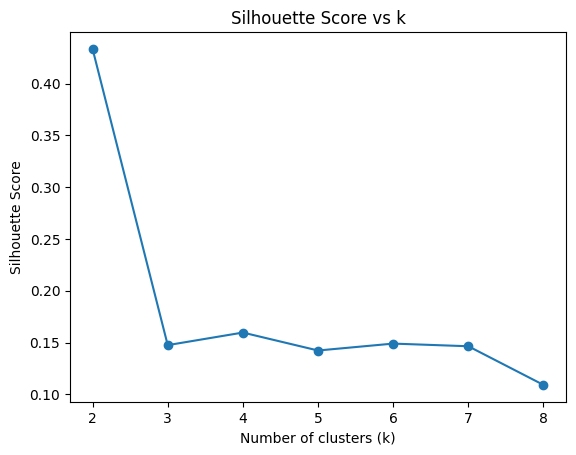


Cluster sizes:
cluster
0    20975
1     8257
2    14218
3     1761
Name: count, dtype: int64

Numeric feature means by cluster:
           age  balance    day  campaign   pdays  previous  \
cluster                                                      
0        33.85   928.25  15.90      2.28   -1.00      0.00   
1        40.95  1556.88  14.29      2.06  224.58      3.18   
2        51.45  1913.10  15.73      2.46   -1.00      0.00   
3        40.40  1171.99  22.41     14.33   -1.00      0.00   

         No_Previous_contact  Not_contacted_for_prior_campaign  \
cluster                                                          
0                        1.0                               1.0   
1                        0.0                               0.0   
2                        1.0                               1.0   
3                        1.0                               1.0   

         Never_contacted_before_No_Camapign_no_contact  
cluster                                     

In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ---------- 0) Base dataframe ----------
base_df = df7.copy()
if 'y' in base_df.columns:
    base_df = base_df.drop(columns=['y'])

# ---------- 1) Feature sets ----------
num_features = [
    'age', 'balance', 'day', 'campaign', 'pdays', 'previous',
    'No_Previous_contact', 'Not_contacted_for_prior_campaign', 'Never_contacted_before_No_Camapign_no_contact'
]

cat_features = [
    'job','marital','education','default','housing','loan','contact','month','poutcome'
    # removed 'yearly_balance'
]

use_cols = num_features + cat_features
X = base_df[use_cols].copy()

# ---------- 2) Preprocess ----------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_features)
    ]
)

# ---------- 3) Test different k ----------
sil_scores = {}
for k in range(2, 9):  # try k=2 to k=8
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clusterer', kmeans)
    ])
    labels = pipe.fit_predict(X)
    X_proc = pipe.named_steps['preprocessor'].transform(X)
    sil = silhouette_score(X_proc, labels)
    sil_scores[k] = sil
    print(f"k={k}, silhouette={sil:.3f}")

# ---------- 4) Plot silhouette scores ----------
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

# ---------- 5) Fit final model with k=4 ----------
kmeans_final = KMeans(n_clusters=4, n_init=20, random_state=42)
pipe_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', kmeans_final)
])
base_df['cluster'] = pipe_final.fit_predict(X)

# ---------- 6) Cluster profiles ----------
print("\nCluster sizes:")
print(base_df['cluster'].value_counts().sort_index())

print("\nNumeric feature means by cluster:")
print(base_df.groupby('cluster')[num_features].mean().round(2))

def top_cat_share(s: pd.Series) -> str:
    vc = s.value_counts(normalize=True)
    if vc.empty:
        return "N/A"
    top = vc.index[0]
    pct = vc.iloc[0]
    return f"{top} ({pct:.0%})"

cat_summary = (
    base_df.groupby('cluster')[cat_features]
           .agg(top_cat_share)
           .reset_index()
)
print("\nTop categorical level per cluster (with share):")
print(cat_summary)


In [8]:
# Make sure original df7 still has 'y'
# Merge clusters back into df7
df7_with_clusters = df7.copy()
df7_with_clusters['cluster'] = base_df['cluster']  # align by index

# Calculate subscription rate (y = yes/no)
conv_rate = (
    df7_with_clusters
    .groupby('cluster')['y']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)

# Filter only "yes"
conv_rate_yes = conv_rate[conv_rate['y'] == 'yes'][['cluster','proportion']]
conv_rate_yes.rename(columns={'proportion':'conversion_rate'}, inplace=True)

print("\nConversion rate by cluster:")
print(conv_rate_yes)

# Optional: count + conversion side by side
summary = (
    df7_with_clusters.groupby('cluster')['y']
    .agg(total='count', yes_count=lambda x: (x=='yes').sum())
    .reset_index()
)
summary['conversion_rate'] = summary['yes_count'] / summary['total']
print("\nCluster subscription summary:")
print(summary)



Conversion rate by cluster:
   cluster  conversion_rate
1        0         0.094732
3        1         0.230713
5        2         0.092629
7        3         0.045429

Cluster subscription summary:
   cluster  total  yes_count  conversion_rate
0        0  20975       1987         0.094732
1        1   8257       1905         0.230713
2        2  14218       1317         0.092629
3        3   1761         80         0.045429


In [9]:
# Map cluster numbers to descriptive labels
cluster_labels = {
    0: "Young First-Timers",
    1: "Engaged Re-contacts",
    2: "Older First-Timers",
    3: "Over-Contacted Non-Responders"
}

df7_with_clusters["cluster_label"] = df7_with_clusters["cluster"].map(cluster_labels)

# Check distribution with labels
print(df7_with_clusters.groupby("cluster_label")["y"].agg(
    total="count",
    yes_count=lambda x: (x=="yes").sum(),
    conversion_rate=lambda x: (x=="yes").mean()
).reset_index())


                   cluster_label  total  yes_count  conversion_rate
0            Engaged Re-contacts   8257       1905         0.230713
1             Older First-Timers  14218       1317         0.092629
2  Over-Contacted Non-Responders   1761         80         0.045429
3             Young First-Timers  20975       1987         0.094732


In [12]:
# Build summary table
summary_table = (
    df7_with_clusters
    .groupby("cluster_label")["y"]
    .agg(
        total="count",
        yes_count=lambda x: (x=="yes").sum(),
        conversion_rate=lambda x: (x=="yes").mean()
    )
    .reset_index()
)

# Sort by conversion_rate (optional)
summary_table = summary_table.sort_values(by="conversion_rate", ascending=False)

print(summary_table)


                   cluster_label  total  yes_count  conversion_rate
0            Engaged Re-contacts   8257       1905         0.230713
3             Young First-Timers  20975       1987         0.094732
1             Older First-Timers  14218       1317         0.092629
2  Over-Contacted Non-Responders   1761         80         0.045429


Focus resources on Engaged Re-contacts: Although smaller, it has 2.5x higher conversion than Clusters Young First-Timers & Older First-Timers.

Clusters Young First-Timers & Older First-Timers: Large pools, but low conversion → might work if offers are personalized (e.g., loan-linked deposit incentives).

Over-Contacted Non-Responders: High cost, low payoff → avoid over-contacting; maybe drop from future campaigns (expensive for marketing)

Saved: slide_engaged_re-contacts.png


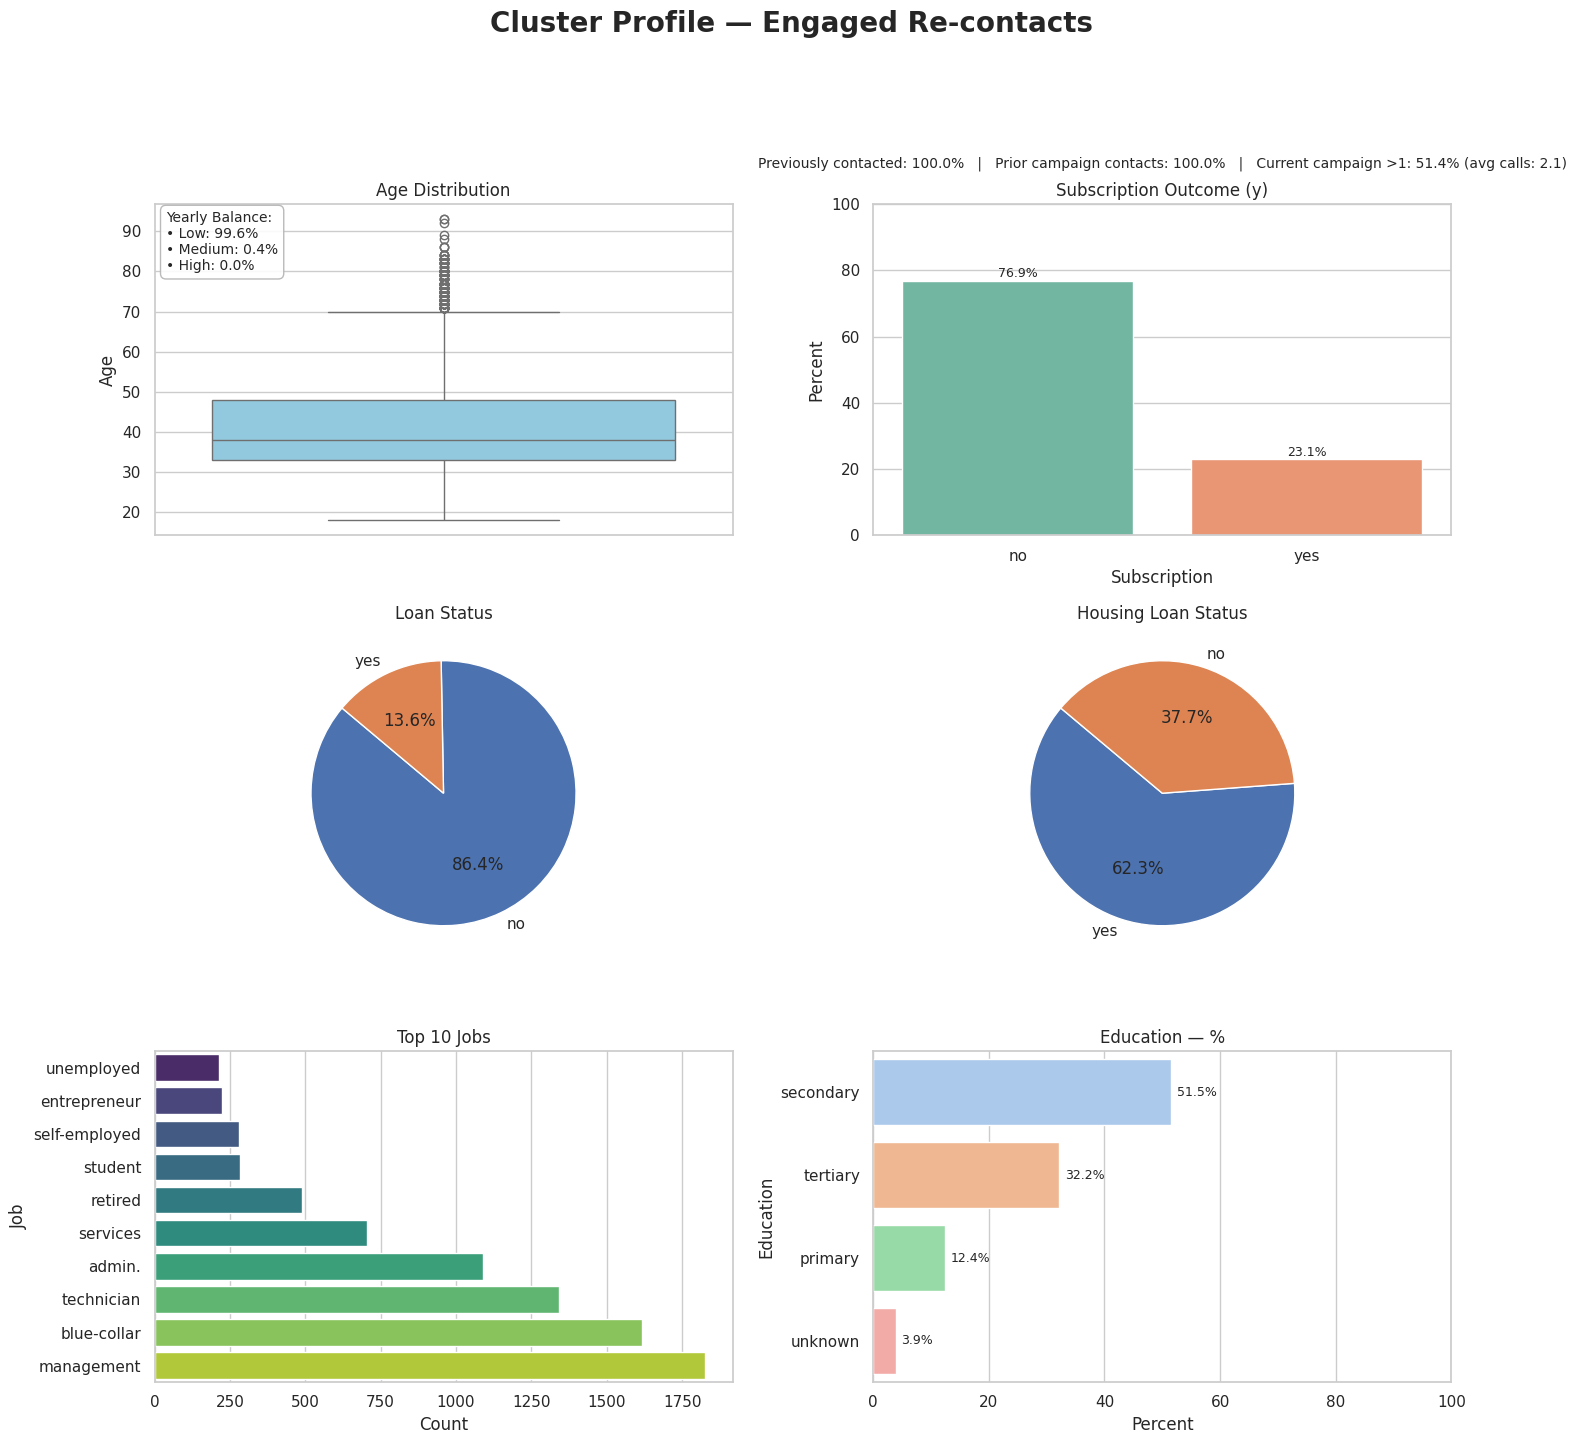

Saved: slide_older_first-timers.png


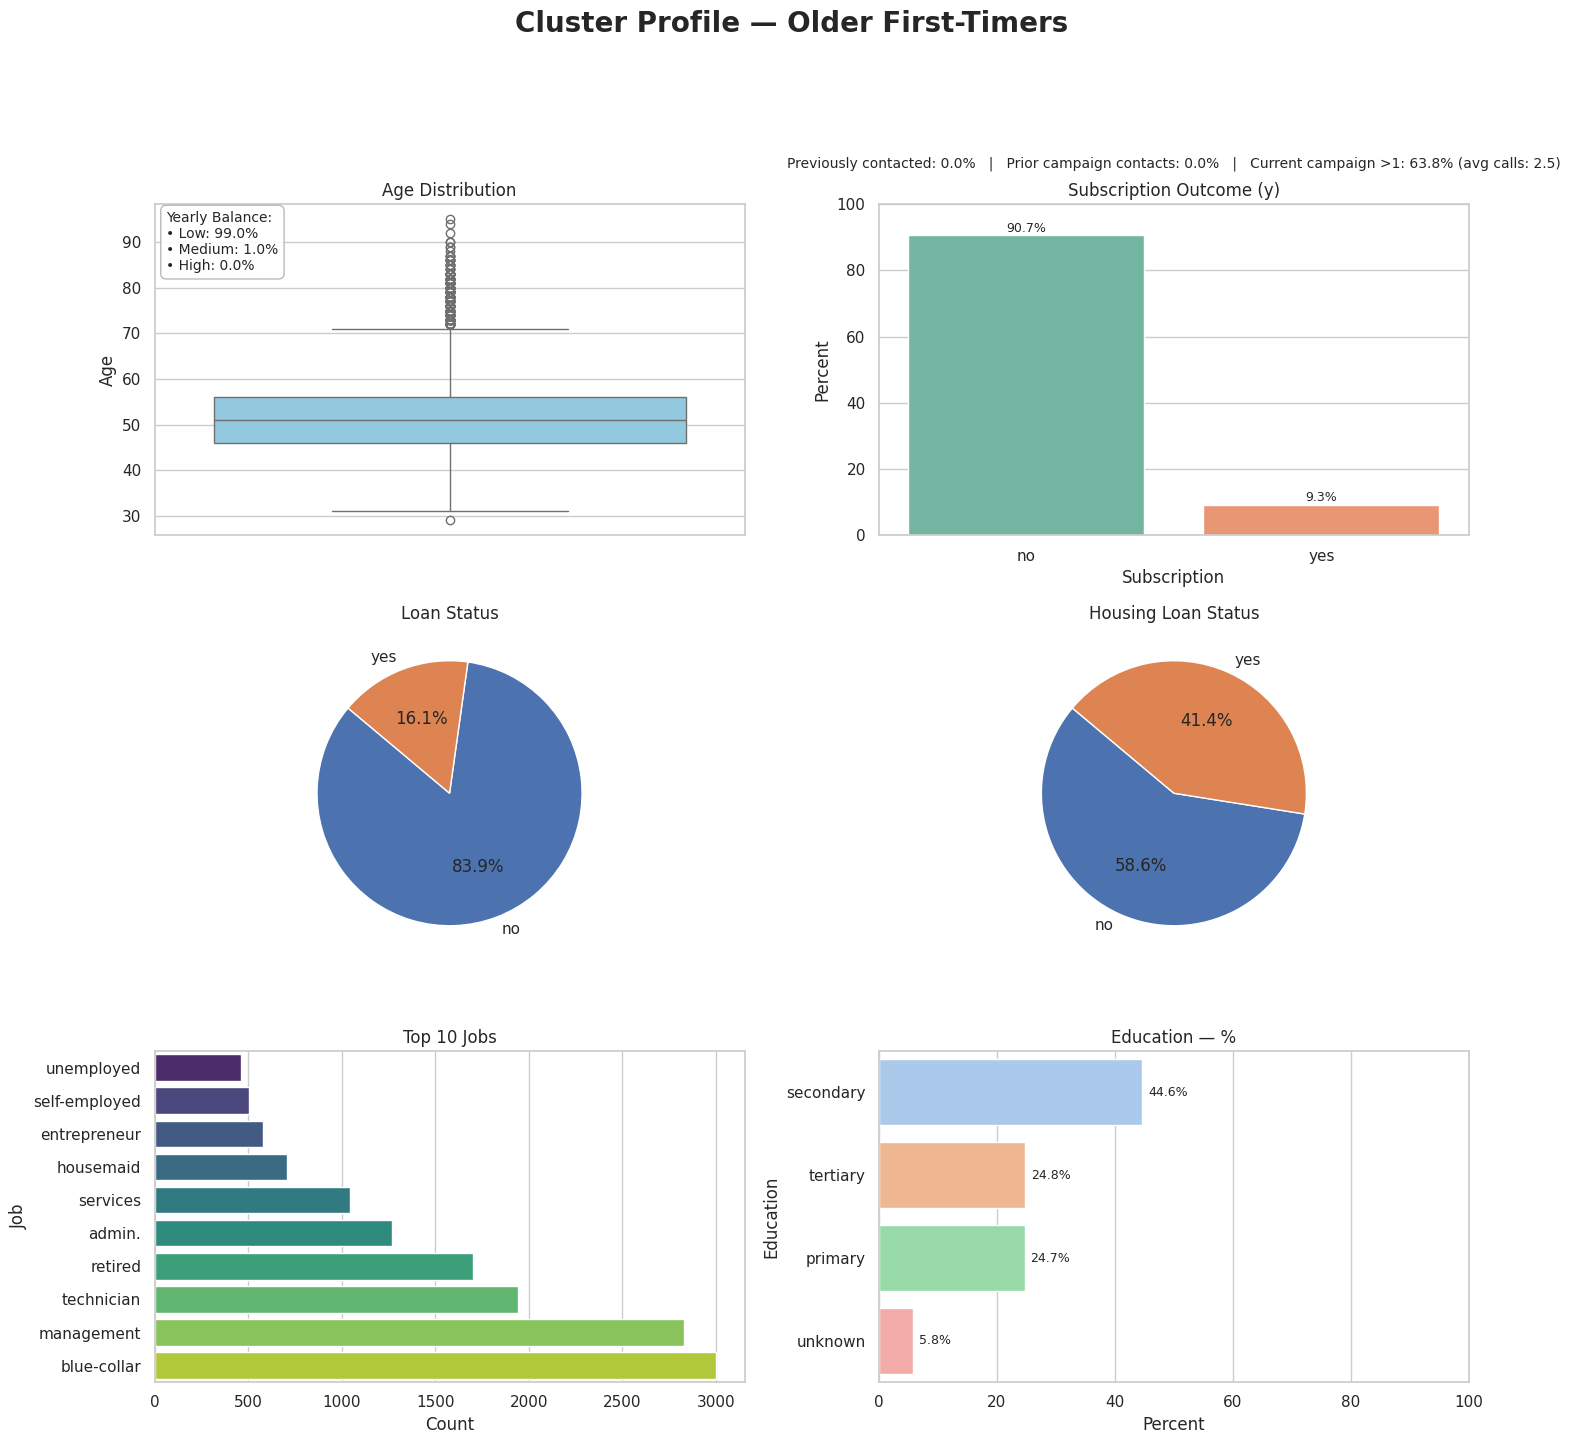

Saved: slide_over-contacted_non-responders.png


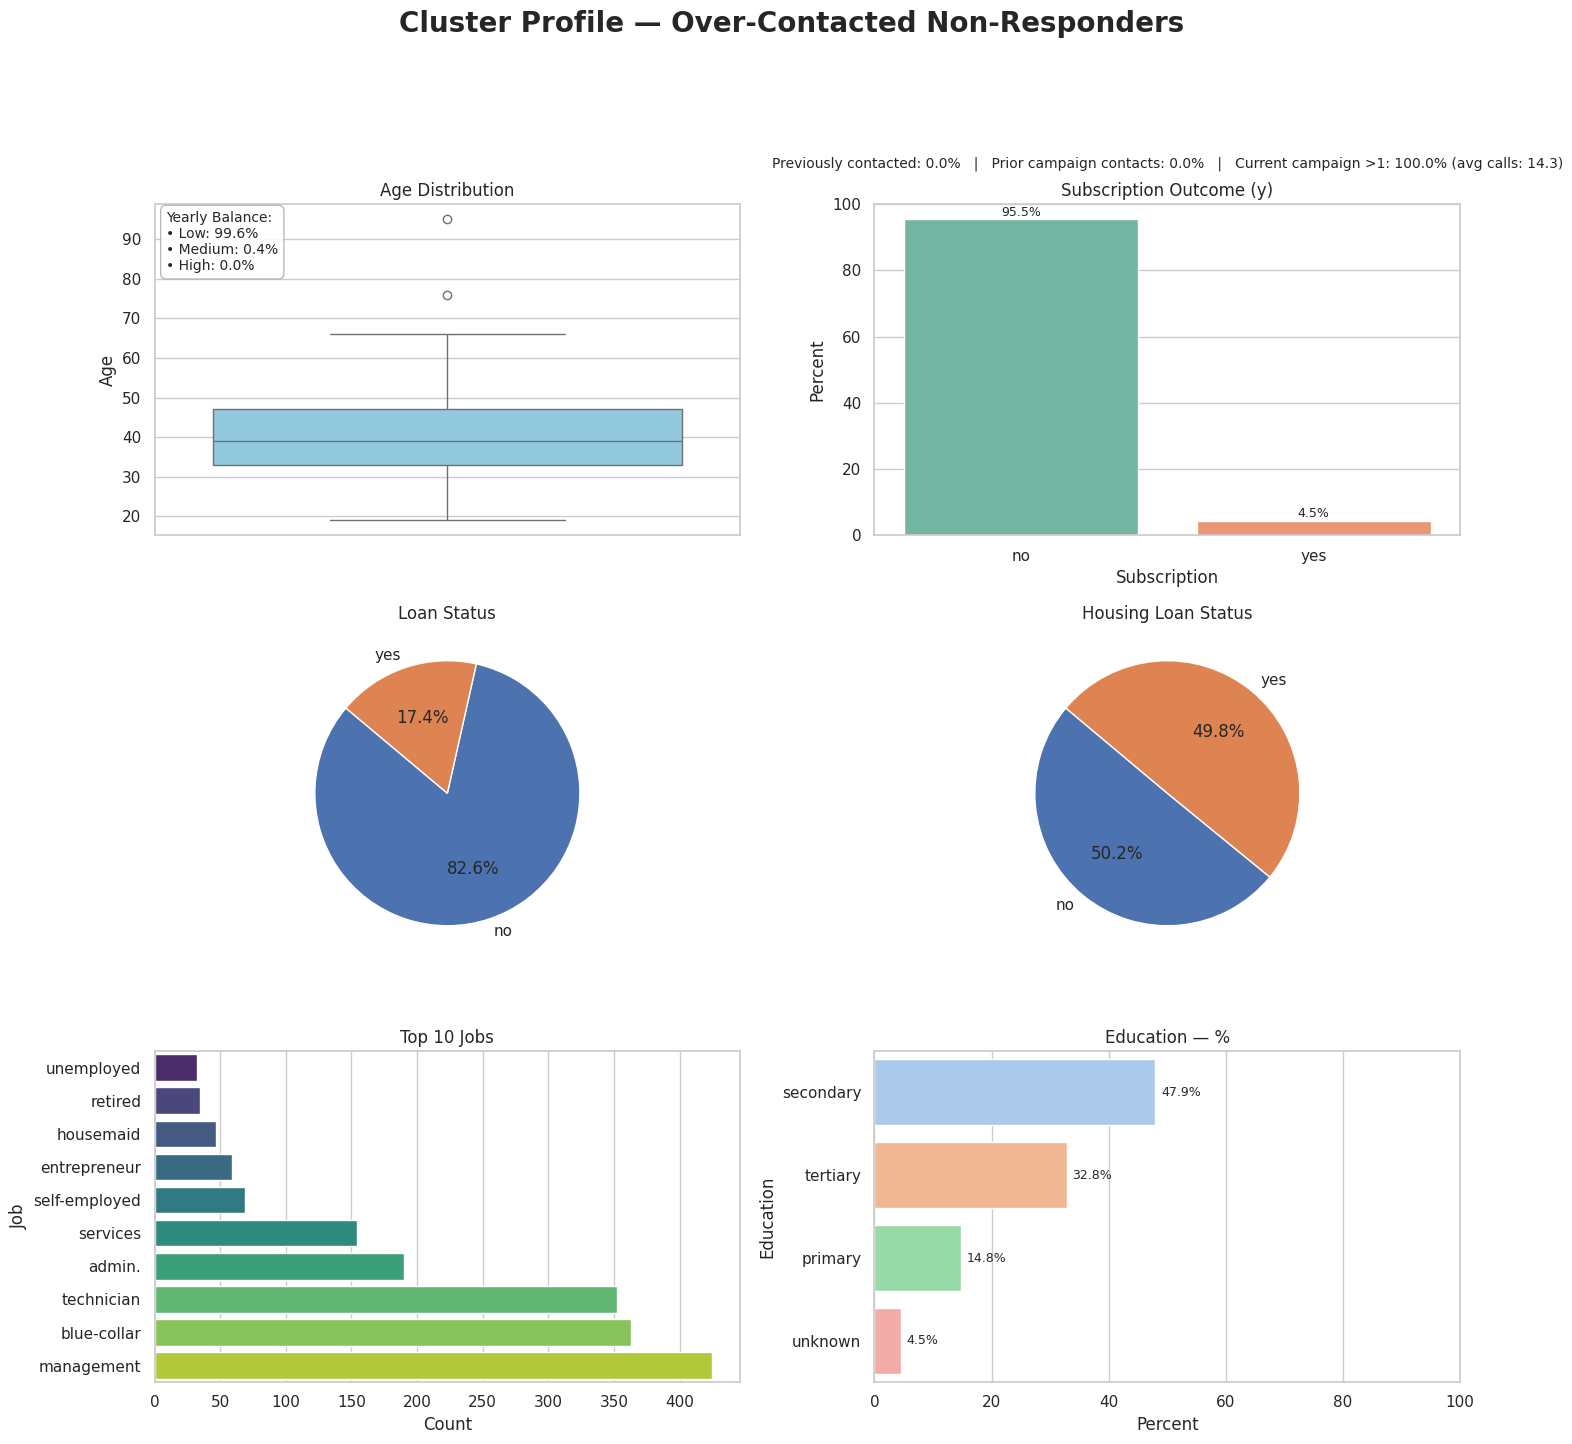

Saved: slide_young_first-timers.png


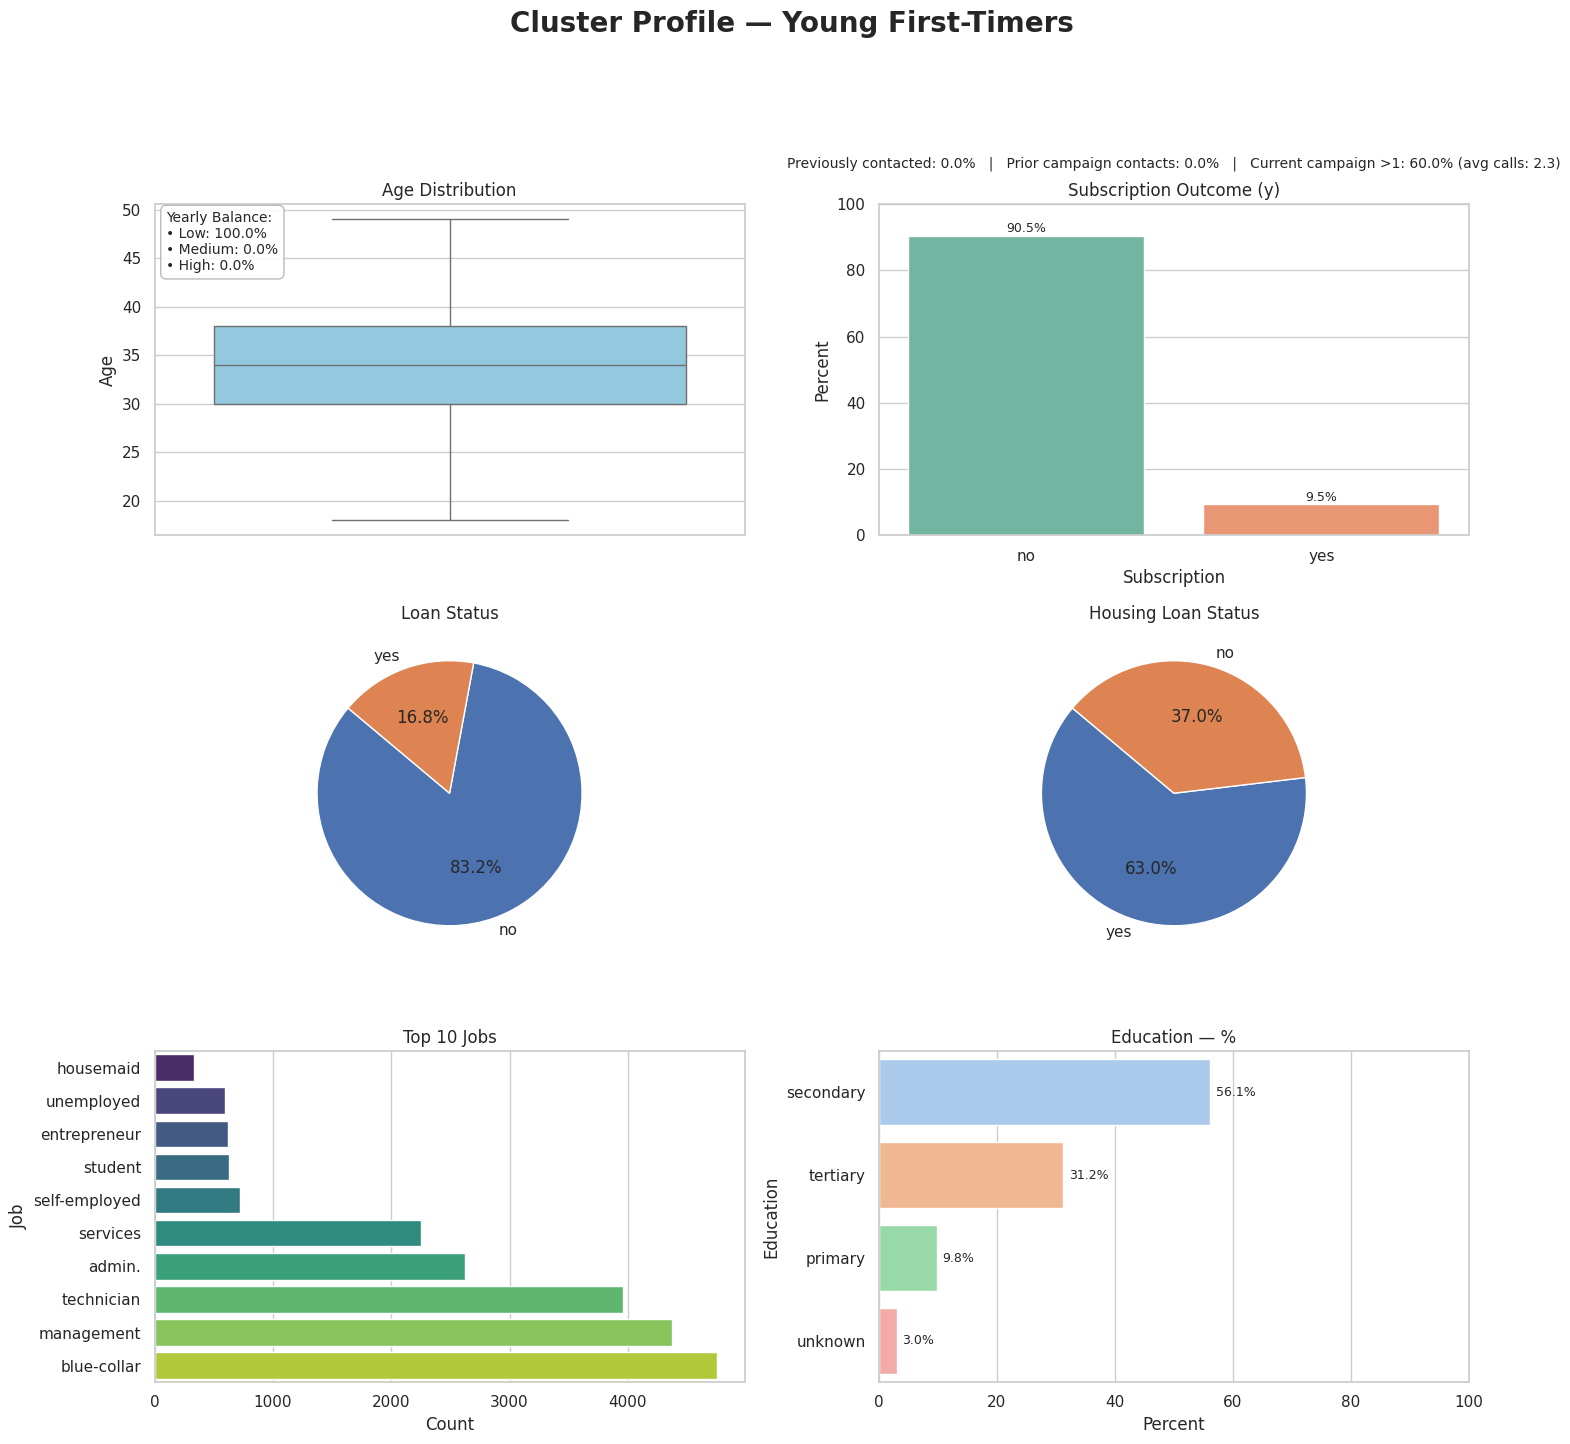

In [18]:
import warnings
warnings.filterwarnings("ignore")

# ====================== IMPORTS ======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ====================== INPUT DATA CHECKS ======================
# Expect either df7_with_clusters (preferred) or df7 (must contain 'cluster')
if 'df7_with_clusters' not in globals():
    if 'df7' in globals():
        df7_with_clusters = df7.copy()
    else:
        raise ValueError("Please define df7_with_clusters or df7 before running this code.")

# Add 'cluster_label' if missing
if 'cluster_label' not in df7_with_clusters.columns:
    if 'cluster' not in df7_with_clusters.columns:
        raise ValueError("No 'cluster_label' or 'cluster' column found.")
    cluster_labels_map = {
        0: "Young First-Timers",
        1: "Engaged Re-contacts",
        2: "Older First-Timers",
        3: "Over-Contacted Non-Responders"
    }
    df7_with_clusters['cluster_label'] = df7_with_clusters['cluster'].map(cluster_labels_map)

# Ensure y is string "yes"/"no" (for plotting)
if df7_with_clusters['y'].dtype != object:
    df7_with_clusters['y'] = df7_with_clusters['y'].astype(str)

# Derive yearly_balance if missing (used for textbox)
if 'yearly_balance' not in df7_with_clusters.columns:
    df7_with_clusters['yearly_balance'] = pd.cut(
        df7_with_clusters['balance'],
        bins=[-np.inf, 20000, 60000, np.inf],
        labels=["Low", "Medium", "High"]
    )

# Ensure contact flags exist (or derive)
if 'No_Previous_contact' not in df7_with_clusters.columns:
    df7_with_clusters['No_Previous_contact'] = (df7_with_clusters['pdays'] < 0).astype(int)
if 'Not_contacted_for_prior_campaign' not in df7_with_clusters.columns:
    df7_with_clusters['Not_contacted_for_prior_campaign'] = (df7_with_clusters['previous'] == 0).astype(int)

# ====================== HELPERS ======================
def _prop_series(s: pd.Series, order=None) -> pd.Series:
    """Return percentage distribution (0-100) rounded to 1dp."""
    vc = s.value_counts(normalize=True) * 100.0
    vc = vc.round(1)
    if order is not None:
        vc = vc.reindex(order, fill_value=0.0)
    return vc

def _percent_bar_h(ax, values, labels):
    """Annotate horizontal bars with % labels at the end."""
    for i, v in enumerate(values):
        ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)

def _add_textbox(ax, text, loc="upper left"):
    """Add a small textbox inside an axes."""
    ha = "left" if loc.endswith("left") else "right"
    va = "top" if loc.startswith("upper") else "bottom"
    x = 0.02 if ha == "left" else 0.98
    y = 0.98 if va == "top" else 0.02
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va,
            fontsize=10, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.7", alpha=0.9))

# ====================== MAIN PLOT FUNCTION ======================
def plot_cluster_slide(df_with_labels: pd.DataFrame, cluster_label: str, save_path: str = None, top_n_jobs: int = 10):
    data = df_with_labels[df_with_labels["cluster_label"] == cluster_label].copy()
    if data.empty:
        print(f"[WARN] No rows for cluster_label='{cluster_label}'")
        return

    # --- Contact stats for subtitle ---
    # Previously contacted before current campaign (pdays >= 0)
    pct_prev_contacted = (data["No_Previous_contact"] == 0).mean() * 100
    # Had contacts in prior campaigns (previous > 0)
    pct_prior_campaign = (data["Not_contacted_for_prior_campaign"] == 0).mean() * 100
    # Re-contacts within current campaign (more than one call now)
    pct_current_recontacts = (data["campaign"] > 1).mean() * 100
    mean_campaign = data["campaign"].mean()

    # Figure: 3 rows x 2 cols = 6 charts
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f"Cluster Profile — {cluster_label}", fontsize=20, fontweight="bold", y=1.03)

    # --- (1) Age boxplot ---
    sns.boxplot(y="age", data=data, ax=axes[0, 0], color="skyblue")
    axes[0, 0].set_title("Age Distribution")
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_ylabel("Age")

    # --- (2) Column chart: Subscription outcome (% yes/no) + extended subtitle ---
    y_props = (data["y"].value_counts(normalize=True).reindex(["no", "yes"], fill_value=0) * 100).round(1)
    y_df = y_props.reset_index()
    y_df.columns = ["Subscription", "Percent"]
    sns.barplot(x="Subscription", y="Percent", data=y_df, ax=axes[0, 1], palette="Set2")
    for i, v in enumerate(y_df["Percent"]):
        axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
    axes[0, 1].set_ylim(0, 100)
    axes[0, 1].set_title("Subscription Outcome (y)")

    subtitle = (
        f"Previously contacted: {pct_prev_contacted:.1f}%   |   "
        f"Prior campaign contacts: {pct_prior_campaign:.1f}%   |   "
        f"Current campaign >1: {pct_current_recontacts:.1f}% (avg calls: {mean_campaign:.1f})"
    )
    # place a bit higher so it doesn't crowd
    axes[0, 1].text(0.5, 1.10, subtitle, transform=axes[0, 1].transAxes,
                    ha="center", va="bottom", fontsize=10)

    # --- (3) Pie: Loan status ---
    loan_props = _prop_series(data["loan"])
    axes[1, 0].pie(loan_props.values, labels=loan_props.index, autopct='%1.1f%%', startangle=140)
    axes[1, 0].set_title("Loan Status")

    # --- (4) Pie: Housing loan status ---
    housing_props = _prop_series(data["housing"])
    axes[1, 1].pie(housing_props.values, labels=housing_props.index, autopct='%1.1f%%', startangle=140)
    axes[1, 1].set_title("Housing Loan Status")

    # --- (5) Bar: Top N jobs (counts) ---
    job_counts = data["job"].value_counts().head(top_n_jobs)[::-1]  # reverse for horizontal bars
    sns.barplot(x=job_counts.values, y=job_counts.index, ax=axes[2, 0], palette="viridis")
    axes[2, 0].set_title(f"Top {top_n_jobs} Jobs")
    axes[2, 0].set_xlabel("Count")
    axes[2, 0].set_ylabel("Job")

    # --- (6) Bar: Education (%), horizontal with labels ---
    edu_props = _prop_series(data["education"])
    edu_df = edu_props.reset_index()
    edu_df.columns = ["Education", "Percent"]
    sns.barplot(x="Percent", y="Education", data=edu_df, ax=axes[2, 1], palette="pastel")
    axes[2, 1].set_title("Education — %")
    axes[2, 1].set_xlim(0, 100)
    _percent_bar_h(axes[2, 1], edu_df["Percent"].values, edu_df["Education"].values)

    # --- Yearly Balance summary textbox (embedded on Age plot) ---
    bal_props = _prop_series(data["yearly_balance"], order=["Low", "Medium", "High"])
    bal_text = "Yearly Balance:\n" + "\n".join([f"• {k}: {v:.1f}%" for k, v in bal_props.items()])
    _add_textbox(axes[0, 0], bal_text, loc="upper left")

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

# ====================== GENERATE ALL SLIDES ======================
labels = sorted(df7_with_clusters["cluster_label"].unique().tolist())
for lbl in labels:
    safe = lbl.lower().replace(" ", "_").replace("/", "_")
    plot_cluster_slide(
        df7_with_clusters,
        cluster_label=lbl,
        save_path=f"slide_{safe}.png",   # remove this arg if you don't want files saved
        top_n_jobs=10
    )






















